## PART D — MINI PROJECT (GenAI-Aligned)
## Task 8: Feature Engineering

## Task 9: Train Deep ANN

In [15]:
# Prepare input labels
X_input = X_features.T 

def one_hot_encode(Y, num_classes):
    m = Y.shape[0]
    Y_oh = np.zeros((num_classes, m))
    for i in range(m):
        Y_oh[Y[i], i] = 1
    return Y_oh

Y_onehot = one_hot_encode(Y_labels, 3)  


In [16]:
# Initialize ANN Parameters
def init_parameters(layer_sizes):
    parameters = {}
    np.random.seed(42)
    for l in range(1, len(layer_sizes)):
        parameters[f"W{l}"] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * 0.01
        parameters[f"b{l}"] = np.zeros((layer_sizes[l],1))
    return parameters

layer_sizes = [4, 5, 5, 3]  # input=4, hidden1=5, hidden2=5, output=3
parameters = init_parameters(layer_sizes)


In [17]:
# Define Activations
# ReLU for hidden layers
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(A):
    return (A > 0).astype(float)

# Softmax for output layer
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)


In [19]:
# Forward Propagation
def forward(X, parameters):
    caches = {}
    A = X
    caches["A0"] = A
    L = len(parameters)//2
    for l in range(1, L):
        Z = parameters[f"W{l}"] @ A + parameters[f"b{l}"]
        A = relu(Z)
        caches[f"Z{l}"] = Z
        caches[f"A{l}"] = A
    Z = parameters[f"W{L}"] @ A + parameters[f"b{L}"]
    A = softmax(Z)
    caches[f"Z{L}"] = Z
    caches[f"A{L}"] = A
    return A, caches

In [20]:
# Compute loss
def compute_loss(Y, A):
    m = Y.shape[1]
    return -np.sum(Y * np.log(A + 1e-8)) / m


In [21]:
# Backpropagation
def backprop(X, Y, parameters, caches):
    grads = {}
    m = X.shape[1]
    L = len(parameters)//2
    
    # Output layer
    A_L = caches[f"A{L}"]
    dZ = A_L - Y
    A_prev = caches[f"A{L-1}"]
    grads[f"dW{L}"] = (1/m) * dZ @ A_prev.T
    grads[f"db{L}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = dZ
    
    # Hidden layers
    for l in reversed(range(1, L)):
        W_next = parameters[f"W{l+1}"]
        dA = W_next.T @ dA_prev
        A_curr = caches[f"A{l}"]
        dZ = dA * relu_derivative(A_curr)
        A_prev = caches[f"A{l-1}"]
        grads[f"dW{l}"] = (1/m) * dZ @ A_prev.T
        grads[f"db{l}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = dZ
        
    return grads

In [22]:
# Update Parameters
def update_parameters(parameters, grads, lr):
    L = len(parameters)//2
    for l in range(1, L+1):
        parameters[f"W{l}"] -= lr * grads[f"dW{l}"]
        parameters[f"b{l}"] -= lr * grads[f"db{l}"]
    return parameters


In [23]:
# Train the ANN
losses = []
epochs = 2000
lr = 0.1

for i in range(epochs):
    A, caches = forward(X_input, parameters)
    loss = compute_loss(Y_onehot, A)
    losses.append(loss)
    grads = backprop(X_input, Y_onehot, parameters, caches)
    parameters = update_parameters(parameters, grads, lr)
    if i % 500 == 0:
        print(f"Epoch {i}, Loss: {loss:.6f}")

Epoch 0, Loss: 1.098612
Epoch 500, Loss: 0.640016
Epoch 1000, Loss: 0.672210
Epoch 1500, Loss: 0.667864


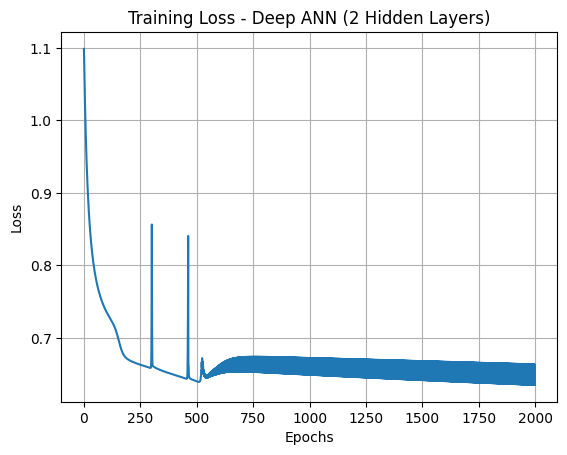

Predicted classes: [1 2 2 2 2]
True classes: [1 2 1 2 1]


In [24]:
# Plot loss and Predict
# Plot loss
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss - Deep ANN (2 Hidden Layers)")
plt.grid(True)
plt.show()

# Predictions
preds = np.argmax(forward(X_input, parameters)[0], axis=0)
print("Predicted classes:", preds)
print("True classes:", np.argmax(Y_onehot, axis=0))


## Task 10: Representation Insight

In [25]:
# Forward pass
A_output, caches = forward(X_input, parameters)

# Print hidden layer outputs
print("Hidden Layer 1 Output (A1):\n", caches["A1"])
print("\nHidden Layer 2 Output (A2):\n", caches["A2"])


Hidden Layer 1 Output (A1):
 [[9.5151995  6.2045444  7.88414466 7.92055374 7.84773559]
 [0.         0.         0.         0.         0.        ]
 [2.42740359 1.59177293 2.01242502 2.01668017 2.00816988]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]

Hidden Layer 2 Output (A2):
 [[1.74889219 0.99185897 1.37574877 1.38380856 1.36768899]
 [0.15188729 0.083333   0.11808558 0.11879872 0.11737243]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [2.43335011 1.38474632 1.91648442 1.92763873 1.90533011]]
